# Projet Machine Learning 


## Imports

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    roc_curve, auc, mean_squared_error, r2_score
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

## 1. Chargement et préparation des données

In [30]:
# ── Lecture ───────────────────────────────────────────────────────────────────
path = "./"
data = pd.read_csv(path + "healthcare_synthetic_data.csv")
print(data.shape)
data.head()

(15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [31]:
# ── Nettoyage ─────────────────────────────────────────────────────────────────
data.drop(columns=["Patient_ID"], inplace=True)

# Variables qualitatives → encodage one-hot (comme model.matrix en R)
# On garde Heart_Disease_Risk et Cholesterol_LDL séparément
qual_cols = ["Gender", "Smoking_Status", "Alcohol_Consumption",
             "Physical_Activity_Level", "Family_History"]

data_encoded = pd.get_dummies(data, columns=qual_cols, drop_first=True)
data_encoded["Heart_Disease_Risk"] = data["Heart_Disease_Risk"].astype(int)

print(data_encoded.shape)
data_encoded.head()

(15000, 21)


,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,...,Sleep_Hours,Heart_Disease_Risk,Gender_1,Smoking_Status_1,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Family_History_1
0,60,146.9,51.3,23.8,140,89,217,151,52,83,...,8,0,False,False,True,False,False,False,True,False
1,53,161.8,76.6,29.3,128,81,203,119,38,116,...,9,0,False,False,False,False,True,False,False,False
2,62,174.7,92.4,30.3,141,100,173,124,45,90,...,7,1,True,False,False,False,False,False,False,False
3,73,173.3,68.9,22.9,136,96,193,117,45,81,...,7,1,True,False,False,False,True,False,False,False
4,52,178.6,79.8,25.0,122,80,236,153,41,79,...,6,0,True,False,True,False,False,True,False,False


---
# PARTIE 1 – Classification : SVC pour `Heart_Disease_Risk`

## 2. Split apprentissage / test (80 / 20) + normalisation

In [32]:
# Variables explicatives et cible
target_clf = "Heart_Disease_Risk"
X_clf = data_encoded.drop(columns=[target_clf, "Cholesterol_LDL"])
y_clf = data_encoded[target_clf]

# Split stratifié (même esprit que set.seed + sample en R)
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=111, stratify=y_clf
)

# Normalisation : train uniquement
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform sur le train
X_test_sc  = scaler.transform(X_test)         # transform seulement sur le test

print(f"Train : {X_train_sc.shape}  |  Test : {X_test_sc.shape}")
print(f"Proportion classe 1 (train) : {y_train.mean():.3f}")

Train : (12000, 19)  |  Test : (3000, 19)
Proportion classe 1 (train) : 0.436


## 3. SVC – Optimisation des hyperparamètres par GridSearchCV

> **Équivalent R :** `tune.svm(..., tunecontrol = tune.control(cross = 10))`  
> En Python, `GridSearchCV` de `scikit-learn` fait exactement la même chose : il teste toutes les combinaisons de paramètres par validation croisée k-fold et retient la meilleure.

### 3.1 Noyau RBF (gaussien)

In [35]:
# Sous-échantillon pour aller plus vite : baisser la taille 12000
rng = np.random.default_rng(42)
idx_small = rng.choice(len(X_train_sc), size=12000, replace=False)
X_small = X_train_sc[idx_small]
y_small = y_train.iloc[idx_small]

# Grille équivalente à tune.svm(cost=c(1,2,3,4,5), gamma=seq(0.02,0.06,by=0.02))
param_rbf = {
    "C"    : [1, 2, 3, 4, 5],
    "gamma": [0.02, 0.04, 0.06]
}

grid_rbf = GridSearchCV(
    SVC(kernel="rbf", probability=True),
    param_rbf,
    cv=10,              # 10-fold CV comme tune.control(cross=10)
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
grid_rbf.fit(X_small, y_small)

print("Meilleurs paramètres RBF :", grid_rbf.best_params_)
print(f"Score CV moyen         : {grid_rbf.best_score_:.4f}")

Fitting 10 folds for each of 15 candidates, totalling 150 fits
Meilleurs paramètres RBF : {'C': 1, 'gamma': 0.04}
Score CV moyen         : 0.7305


In [36]:
# ── Modèle final entraîné sur TOUT le train ───────────────────────────────────
svc_rbf = SVC(
    kernel="rbf",
    C     = grid_rbf.best_params_["C"],
    gamma = grid_rbf.best_params_["gamma"],
    probability=True
)
svc_rbf.fit(X_train_sc, y_train)

pred_rbf   = svc_rbf.predict(X_test_sc)
proba_rbf  = svc_rbf.predict_proba(X_test_sc)[:, 1]

print("Matrice de confusion – SVC RBF :")
print(confusion_matrix(y_test, pred_rbf))
print(f"Accuracy : {accuracy_score(y_test, pred_rbf):.4f}")

Matrice de confusion – SVC RBF :
[[1387  305]
 [ 521  787]]
Accuracy : 0.7247


### 3.2 Noyau Linéaire

In [8]:
param_lin = {"C": [1, 2, 3, 4, 5]}

grid_lin = GridSearchCV(
    SVC(kernel="linear", probability=True),
    param_lin,
    cv=10, scoring="accuracy", n_jobs=-1, verbose=1
)
grid_lin.fit(X_small, y_small)

print("Meilleurs paramètres Linéaire :", grid_lin.best_params_)
print(f"Score CV moyen                : {grid_lin.best_score_:.4f}")

Fitting 10 folds for each of 5 candidates, totalling 50 fits
Meilleurs paramètres Linéaire : {'C': 1}
Score CV moyen                : 0.7114


In [9]:
svc_lin = SVC(
    kernel="linear",
    C=grid_lin.best_params_["C"],
    probability=True
)
svc_lin.fit(X_train_sc, y_train)

pred_lin  = svc_lin.predict(X_test_sc)
proba_lin = svc_lin.predict_proba(X_test_sc)[:, 1]

print("Matrice de confusion – SVC Linéaire :")
print(confusion_matrix(y_test, pred_lin))
print(f"Accuracy : {accuracy_score(y_test, pred_lin):.4f}")

Matrice de confusion – SVC Linéaire :
[[1376  316]
 [ 516  792]]
Accuracy : 0.7227


### 3.3 Noyau Polynomial

In [10]:
param_pol = {
    "C"     : [1, 2, 3, 4, 5],
    "gamma" : [0.02, 0.04, 0.06],
    "degree": [2, 3],
    "coef0" : [0, 0.5, 1, 2]
}

grid_pol = GridSearchCV(
    SVC(kernel="poly", probability=True),
    param_pol,
    cv=10, scoring="accuracy", n_jobs=-1, verbose=1
)
grid_pol.fit(X_small, y_small)

print("Meilleurs paramètres Polynomial :", grid_pol.best_params_)
print(f"Score CV moyen                  : {grid_pol.best_score_:.4f}")

Fitting 10 folds for each of 120 candidates, totalling 1200 fits
Meilleurs paramètres Polynomial : {'C': 4, 'coef0': 0, 'degree': 3, 'gamma': 0.02}
Score CV moyen                  : 0.7230


In [11]:
bp = grid_pol.best_params_
svc_pol = SVC(
    kernel="poly",
    C=bp["C"], gamma=bp["gamma"], degree=bp["degree"], coef0=bp["coef0"],
    probability=True
)
svc_pol.fit(X_train_sc, y_train)

pred_pol  = svc_pol.predict(X_test_sc)
proba_pol = svc_pol.predict_proba(X_test_sc)[:, 1]

print("Matrice de confusion – SVC Polynomial :")
print(confusion_matrix(y_test, pred_pol))
print(f"Accuracy : {accuracy_score(y_test, pred_pol):.4f}")

Matrice de confusion – SVC Polynomial :
[[1412  280]
 [ 550  758]]
Accuracy : 0.7233


### 3.4 Noyau Radial (séparé du RBF comme en R)

In [12]:
# On peut varier C et gamma sur un sous-ensemble encore plus petit si besoin
idx_1000 = rng.choice(len(X_train_sc), size=5000, replace=False)
X_1000   = X_train_sc[idx_1000]
y_1000   = y_train.iloc[idx_1000]

param_rad = {
    "C"    : [1, 2, 3, 4, 5],
    "gamma": [0.02, 0.04, 0.06]
}

grid_rad = GridSearchCV(
    SVC(kernel="rbf", probability=True),
    param_rad,
    cv=10, scoring="accuracy", n_jobs=-1, verbose=1
)
grid_rad.fit(X_1000, y_1000)

print("Meilleurs paramètres Radial :", grid_rad.best_params_)
print(f"Score CV moyen              : {grid_rad.best_score_:.4f}")

Fitting 10 folds for each of 15 candidates, totalling 150 fits
Meilleurs paramètres Radial : {'C': 2, 'gamma': 0.06}
Score CV moyen              : 0.7430


In [13]:
svc_rad = SVC(
    kernel="rbf",
    C=grid_rad.best_params_["C"],
    gamma=grid_rad.best_params_["gamma"],
    probability=True
)
svc_rad.fit(X_train_sc, y_train)

pred_rad  = svc_rad.predict(X_test_sc)
proba_rad = svc_rad.predict_proba(X_test_sc)[:, 1]

print("Matrice de confusion – SVC Radial :")
print(confusion_matrix(y_test, pred_rad))
print(f"Accuracy : {accuracy_score(y_test, pred_rad):.4f}")

Matrice de confusion – SVC Radial :
[[1384  308]
 [ 508  800]]
Accuracy : 0.7280


## 4. Courbes ROC – comparaison des noyaux SVC

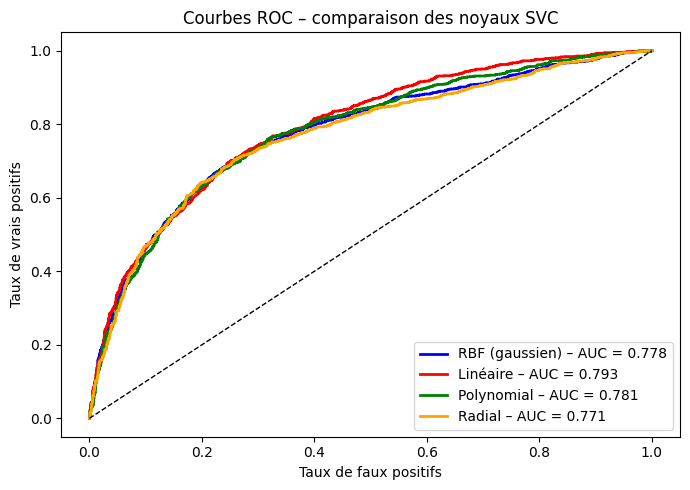

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

for label, proba, color in [
    ("RBF (gaussien)", proba_rbf, "blue"),
    ("Linéaire",       proba_lin, "red"),
    ("Polynomial",     proba_pol, "green"),
    ("Radial",         proba_rad, "orange"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{label} – AUC = {auc_val:.3f}")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC – comparaison des noyaux SVC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. Tableau récapitulatif SVC

In [16]:
resultats_clf = []
for label, pred, proba in [
    ("SVC – RBF (gaussien)", pred_rbf, proba_rbf),
    ("SVC – Linéaire",       pred_lin, proba_lin),
    ("SVC – Polynomial",     pred_pol, proba_pol),
    ("SVC – Radial",         pred_rad, proba_rad),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    resultats_clf.append({
        "Modèle"  : label,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "AUC"     : round(auc(fpr, tpr), 4)
    })

df_clf = pd.DataFrame(resultats_clf).sort_values("Accuracy", ascending=False)
df_clf.reset_index(drop=True, inplace=True)
print(df_clf.to_string(index=False))

              Modèle  Accuracy    AUC
        SVC – Radial    0.7280 0.7715
SVC – RBF (gaussien)    0.7247 0.7778
    SVC – Polynomial    0.7233 0.7815
      SVC – Linéaire    0.7227 0.7927


---
# PARTIE 2 – Régression : SVR pour `Cholesterol_LDL`

## 6. Split + normalisation

In [17]:
target_reg = "Cholesterol_LDL"
X_reg = data_encoded.drop(columns=[target_reg, "Heart_Disease_Risk"])
y_reg = data_encoded[target_reg]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=111
)

scaler_reg = StandardScaler()
X_tr_sc = scaler_reg.fit_transform(X_tr)
X_te_sc = scaler_reg.transform(X_te)

# Sous-échantillon 5000 pour le tuning
idx_svr = rng.choice(len(X_tr_sc), size=5000, replace=False)
X_svr_small = X_tr_sc[idx_svr]
y_svr_small = y_tr.iloc[idx_svr]

print(f"Train : {X_tr_sc.shape}  |  Test : {X_te_sc.shape}")

Train : (12000, 19)  |  Test : (3000, 19)


## 7. SVR – Optimisation par GridSearchCV

Même logique que pour le SVC : `GridSearchCV` avec `cv=10` et `scoring="neg_root_mean_squared_error"` (RMSE).

### 7.1 Noyau RBF (gaussien)

In [18]:
param_svr_rbf = {
    "C"    : [1, 2, 3, 4, 5],
    "gamma": [0.02, 0.04, 0.06]
}

grid_svr_rbf = GridSearchCV(
    SVR(kernel="rbf"),
    param_svr_rbf,
    cv=10,
    scoring="neg_root_mean_squared_error",  # équivalent RMSE
    n_jobs=-1,
    verbose=1
)
grid_svr_rbf.fit(X_svr_small, y_svr_small)

print("Meilleurs paramètres SVR RBF :", grid_svr_rbf.best_params_)
print(f"RMSE CV                      : {-grid_svr_rbf.best_score_:.4f}")

Fitting 10 folds for each of 15 candidates, totalling 150 fits
Meilleurs paramètres SVR RBF : {'C': 4, 'gamma': 0.02}
RMSE CV                      : 10.2434


In [19]:
svr_rbf = SVR(
    kernel="rbf",
    C=grid_svr_rbf.best_params_["C"],
    gamma=grid_svr_rbf.best_params_["gamma"]
)
svr_rbf.fit(X_tr_sc, y_tr)

pred_svr_rbf = svr_rbf.predict(X_te_sc)
rmse_rbf = np.sqrt(mean_squared_error(y_te, pred_svr_rbf))
r2_rbf   = r2_score(y_te, pred_svr_rbf)
print(f"RMSE SVR RBF : {rmse_rbf:.4f}  |  R² : {r2_rbf:.4f}")

RMSE SVR RBF : 10.2470  |  R² : 0.6528


### Graphe des résidus (train) – équivalent de `gplot.res` en R

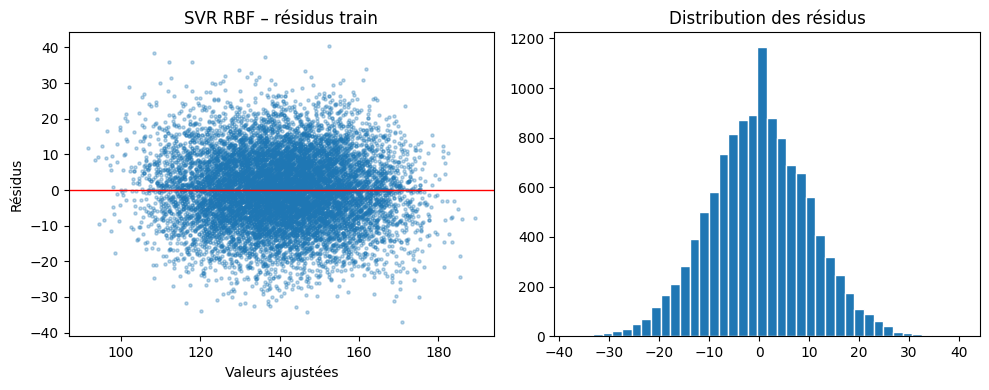

In [20]:
def plot_residuals(fitted, residuals, title="Résidus"):
    """Graphe résidus vs valeurs ajustées (équivalent gplot.res du TP R)."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(fitted, residuals, alpha=0.3, s=5)
    axes[0].axhline(0, color="red", lw=1)
    axes[0].set_xlabel("Valeurs ajustées")
    axes[0].set_ylabel("Résidus")
    axes[0].set_title(title)
    axes[1].hist(residuals, bins=40, edgecolor="white")
    axes[1].set_title("Distribution des résidus")
    plt.tight_layout()
    plt.show()

fit_rbf = svr_rbf.predict(X_tr_sc)
res_rbf = fit_rbf - y_tr
plot_residuals(fit_rbf, res_rbf, "SVR RBF – résidus train")

### 7.2 Noyau Linéaire

In [21]:
param_svr_lin = {"C": [0.5, 1, 2, 3, 5]}

grid_svr_lin = GridSearchCV(
    SVR(kernel="linear"),
    param_svr_lin,
    cv=10, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=1
)
grid_svr_lin.fit(X_svr_small, y_svr_small)

print("Meilleurs paramètres SVR Linéaire :", grid_svr_lin.best_params_)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
Meilleurs paramètres SVR Linéaire : {'C': 0.5}


RMSE SVR Linéaire : 10.0869  |  R² : 0.6636


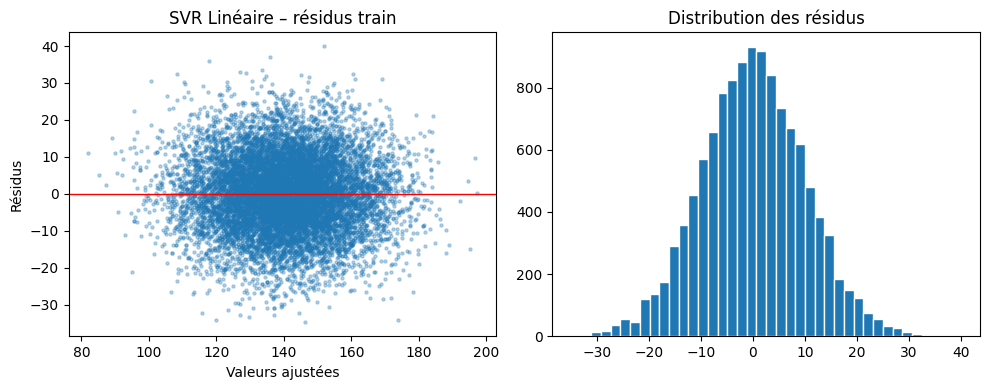

In [22]:
svr_lin = SVR(kernel="linear", C=grid_svr_lin.best_params_["C"])
svr_lin.fit(X_tr_sc, y_tr)

pred_svr_lin = svr_lin.predict(X_te_sc)
rmse_lin = np.sqrt(mean_squared_error(y_te, pred_svr_lin))
r2_lin   = r2_score(y_te, pred_svr_lin)
print(f"RMSE SVR Linéaire : {rmse_lin:.4f}  |  R² : {r2_lin:.4f}")

fit_lin = svr_lin.predict(X_tr_sc)
plot_residuals(fit_lin, fit_lin - y_tr, "SVR Linéaire – résidus train")

### 7.3 Noyau Polynomial

In [23]:
param_svr_pol = {
    "C"     : [1, 2, 3, 5],
    "gamma" : [0.02, 0.04, 0.06],
    "degree": [2, 3],
    "coef0" : [0, 0.5, 1]
}

grid_svr_pol = GridSearchCV(
    SVR(kernel="poly"),
    param_svr_pol,
    cv=10, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=1
)
grid_svr_pol.fit(X_svr_small, y_svr_small)

print("Meilleurs paramètres SVR Polynomial :", grid_svr_pol.best_params_)

Fitting 10 folds for each of 72 candidates, totalling 720 fits
Meilleurs paramètres SVR Polynomial : {'C': 2, 'coef0': 1, 'degree': 2, 'gamma': 0.02}


RMSE SVR Polynomial : 10.1278  |  R² : 0.6609


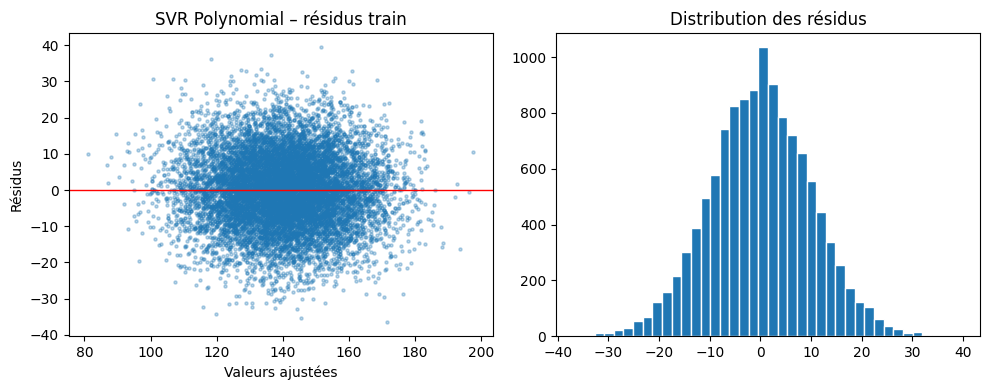

In [24]:
bp_pol = grid_svr_pol.best_params_
svr_pol = SVR(
    kernel="poly",
    C=bp_pol["C"], gamma=bp_pol["gamma"],
    degree=bp_pol["degree"], coef0=bp_pol["coef0"]
)
svr_pol.fit(X_tr_sc, y_tr)

pred_svr_pol = svr_pol.predict(X_te_sc)
rmse_pol = np.sqrt(mean_squared_error(y_te, pred_svr_pol))
r2_pol   = r2_score(y_te, pred_svr_pol)
print(f"RMSE SVR Polynomial : {rmse_pol:.4f}  |  R² : {r2_pol:.4f}")

fit_pol = svr_pol.predict(X_tr_sc)
plot_residuals(fit_pol, fit_pol - y_tr, "SVR Polynomial – résidus train")

### 7.4 Noyau Radial

In [25]:
param_svr_rad = {
    "C"    : [1, 2, 3, 5],
    "gamma": [0.02, 0.04, 0.06]
}

grid_svr_rad = GridSearchCV(
    SVR(kernel="rbf"),
    param_svr_rad,
    cv=10, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=1
)
grid_svr_rad.fit(X_svr_small, y_svr_small)

print("Meilleurs paramètres SVR Radial :", grid_svr_rad.best_params_)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Meilleurs paramètres SVR Radial : {'C': 3, 'gamma': 0.02}


RMSE SVR Radial : 10.2442  |  R² : 0.6530


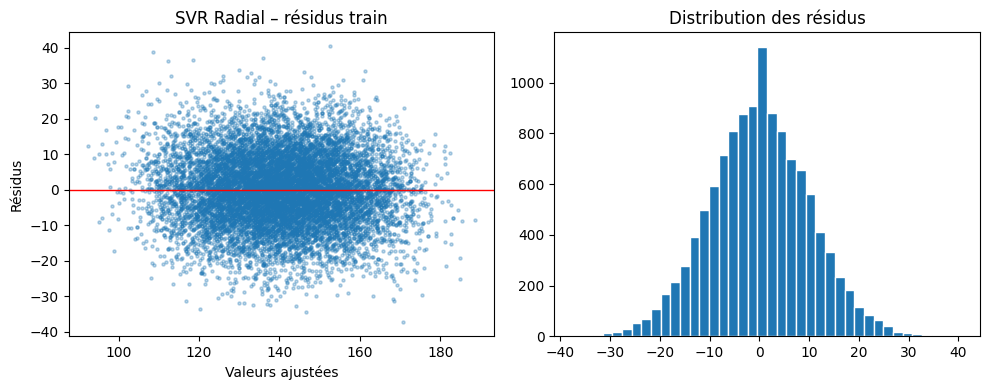

In [26]:
svr_rad = SVR(
    kernel="rbf",
    C=grid_svr_rad.best_params_["C"],
    gamma=grid_svr_rad.best_params_["gamma"]
)
svr_rad.fit(X_tr_sc, y_tr)

pred_svr_rad = svr_rad.predict(X_te_sc)
rmse_rad = np.sqrt(mean_squared_error(y_te, pred_svr_rad))
r2_rad   = r2_score(y_te, pred_svr_rad)
print(f"RMSE SVR Radial : {rmse_rad:.4f}  |  R² : {r2_rad:.4f}")

fit_rad = svr_rad.predict(X_tr_sc)
plot_residuals(fit_rad, fit_rad - y_tr, "SVR Radial – résidus train")

## 8. Tableau récapitulatif SVR + graphe prédictions vs réel

In [27]:
resultats_svr = pd.DataFrame([
    {"Noyau": "RBF (gaussien)", "RMSE": round(rmse_rbf, 4), "R²": round(r2_rbf, 4)},
    {"Noyau": "Linéaire",       "RMSE": round(rmse_lin, 4), "R²": round(r2_lin, 4)},
    {"Noyau": "Polynomial",     "RMSE": round(rmse_pol, 4), "R²": round(r2_pol, 4)},
    {"Noyau": "Radial",         "RMSE": round(rmse_rad, 4), "R²": round(r2_rad, 4)},
]).sort_values("RMSE")

print(resultats_svr.to_string(index=False))

         Noyau    RMSE     R²
      Linéaire 10.0869 0.6636
    Polynomial 10.1278 0.6609
        Radial 10.2442 0.6530
RBF (gaussien) 10.2470 0.6528


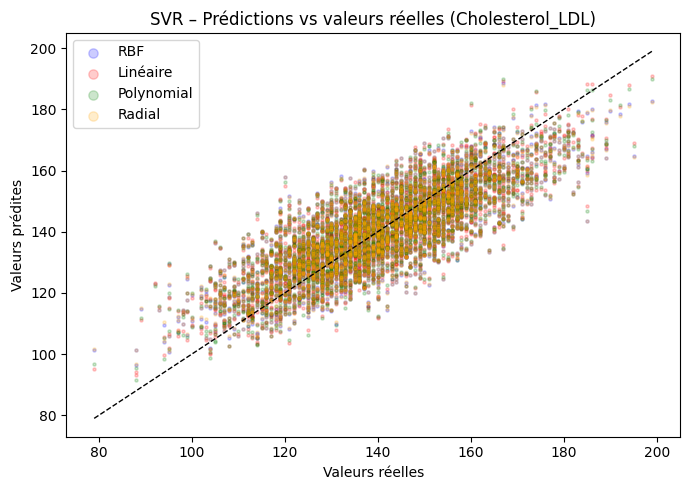

In [28]:
# ── Prédictions vs valeurs réelles (équivalent du ggplot en R) ────────────────
fig, ax = plt.subplots(figsize=(7, 5))

colors = {"RBF": "blue", "Linéaire": "red", "Polynomial": "green", "Radial": "orange"}
for label, pred_svr, color in [
    ("RBF",        pred_svr_rbf, "blue"),
    ("Linéaire",   pred_svr_lin, "red"),
    ("Polynomial", pred_svr_pol, "green"),
    ("Radial",     pred_svr_rad, "orange"),
]:
    ax.scatter(y_te, pred_svr, alpha=0.2, s=5, color=color, label=label)

lims = [y_te.min(), y_te.max()]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("Valeurs réelles")
ax.set_ylabel("Valeurs prédites")
ax.set_title("SVR – Prédictions vs valeurs réelles (Cholesterol_LDL)")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()